In [2]:
# library imports
import os
import sys
from time import time
from stable_baselines3 import PPO
from datetime import datetime
from stable_baselines3.common.vec_env import VecMonitor

# custom imports
from evorl.rl.evolve_drone_env import *
# from randomization import *
from evorl.ctrl_allocation import *
from quadcopter_animation import animation
import matplotlib.pyplot as plt

python version: 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
stable_baselines3 version: 2.4.1
torch version: 2.5.1
cuda available: True
cuda version: 12.4
cudnn version: 90100
device: cuda


[[-1564.06684458 -1564.06684458  1564.06684458  1564.06684458]
 [ 1101.07145935 -1101.07145935 -1101.07145935  1101.07145935]
 [  105.58579874  -105.58579874   105.58579874  -105.58579874]]
[[-1733.47596437  1207.65597781 -1081.2269101   1596.93338146]
 [ -817.85034027 -1179.47095421  1244.36382736   810.35315723]
 [ -200.41485379   171.03051918   264.93993162  -233.9642885 ]]


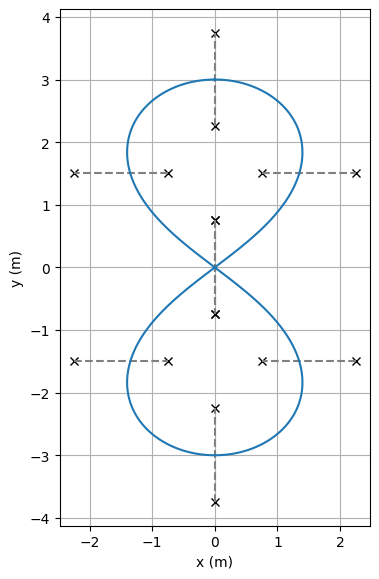

In [13]:
# DEFINE CONTROL ALLOCATION
Bf_std, Bm_std = ctrl_allocation_standard()

Bf_lambda, Bm_lambda = ctrl_allocation_lambda()

Bf_alpha, Bm_alpha = ctrl_allocation_alpha()

# DEFINE RACE TRACK
r = 1.5
gate_pos = np.array([
    [ r,  -r, -1.5],
    [ 0,   0, -1.5],
    [-r,   r, -1.5],
    [ 0, 2*r, -1.5],
    [ r,   r, -1.5],
    [ 0,   0, -1.5],
    [-r,  -r, -1.5],
    [ 0,-2*r, -1.5]
])
gate_yaw = np.array([1,2,1,0,-1,-2,-1,0])*np.pi/2
start_pos = gate_pos[0] + np.array([0,-1.,0])

fig1 = plt.figure(figsize=(4, 8))
ax1 = fig1.add_subplot(111)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax1.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax1.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Parameter for the lemniscate
a = np.sqrt(2) * r
b = 2.8

# Generate theta values for parametric equations
theta = np.linspace(0, 2 * np.pi, 1000)

# Parametric equations for the lemniscate
x = (a * np.sqrt(2) * np.cos(theta)) / (1 + np.sin(theta)**2)
y = (b * np.sqrt(2) * np.cos(theta) * np.sin(theta)) / (1 + np.sin(theta)**2)

ax1.plot(y, x)

ax1.grid()
    
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal', adjustable='box')

In [8]:
std_env = Drone3DGates(
    num_envs=1,
    Bf=Bf_std,
    Bm=Bm_std,
    gates_pos=gate_pos,
    gate_yaw=gate_yaw,
    start_pos=start_pos,
    # randomization=randomization,
    initialize_at_random_gates=False,
    gates_ahead=1,
    num_state_history=0,
    num_action_history=0,
    history_step_size=1,
    # param_input=args.param_input,
    # param_input_noise=args.param_input_noise
)

lambda_env = Drone3DGates(
    num_envs=1,
    Bf=Bf_lambda,
    Bm=Bm_lambda,
    gates_pos=gate_pos,
    gate_yaw=gate_yaw,
    start_pos=start_pos,
    # randomization=randomization,
    initialize_at_random_gates=False,
    gates_ahead=1,
    num_state_history=0,
    num_action_history=0,
    history_step_size=1,
    # param_input=args.param_input,
    # param_input_noise=args.param_input_noise
)

alpha_env = Drone3DGates(
    num_envs=1,
    Bf=Bf_alpha,
    Bm=Bm_alpha,
    gates_pos=gate_pos,
    gate_yaw=gate_yaw,
    start_pos=start_pos,
    # randomization=randomization,
    initialize_at_random_gates=False,
    gates_ahead=1,
    num_state_history=0,
    num_action_history=0,
    history_step_size=1,
    # param_input=args.param_input,
    # param_input_noise=args.param_input_noise
)

/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


In [9]:
# MODEL DEFINITION
policy_kwargs = dict(activation_fn=torch.nn.ReLU, net_arch=[dict(pi=[64, 64, 64], vf=[64, 64, 64])], log_std_init = 0)
std_model = PPO(
    "MlpPolicy",
    std_env,
    policy_kwargs=policy_kwargs,
    verbose=0,
    tensorboard_log=None,
    n_steps=1000,
    batch_size=5000,
    n_epochs=10,
    gamma=0.999
)

std_model = PPO.load('models/3_layers_tau/r150/standard_drone_4/100000000')
# std_model = PPO.load('models/random/r150/p30t90_drone_1/100000000')
lambda_model = PPO(
    "MlpPolicy",
    lambda_env,
    policy_kwargs=policy_kwargs,
    verbose=0,
    tensorboard_log=None,
    n_steps=1000,
    batch_size=5000,
    n_epochs=10,
    gamma=0.999
)

lambda_model = PPO.load('models/3_layers_tau/r150/lambda_drone_5/100000000')
# lambda_model = PPO.load('models/random/r150/p30t90_drone_1/100000000')
alpha_model = PPO(
    "MlpPolicy",
    alpha_env,
    policy_kwargs=policy_kwargs,
    verbose=0,
    tensorboard_log=None,
    n_steps=1000,
    batch_size=5000,
    n_epochs=10,
    gamma=0.999
)

alpha_model = PPO.load('models/3_layers_tau_2E8/r150/alpha_drone_4/200000000')

/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 5000, but because the `RolloutBuffer` is of size `n_steps * n_envs = 1000`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 1000
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=1000 and n_envs=1)
  warnings.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run 

In [10]:
# TESTING
std_env.reset()

std_position_x = []
std_position_y = []
std_position_z = []
std_speed = []

# do 1000 steps and print state and action
for i in range(1000):
    # print('step', i)
    num = std_env.num_state_history+1
    state_len = int(len(std_env.states[0])/num)

    actions, _ = std_model.predict(std_env.states, deterministic=True)
    states, rewards, dones, infos = std_env.step(actions)

    if (i+1) % 500 == 0: 
        print('step', i+1)
        print('rewards=', rewards)
        print('Num gates passed=', infos)
        print('')
    std_position_x.append(std_env.world_states[0,0])
    std_position_y.append(std_env.world_states[0,1])
    std_position_z.append(std_env.world_states[0,2])
    std_speed.append(np.linalg.norm(std_env.world_states[0,3:6]))

# print(f"Max speed: {max(speed)}")
# print(f"Avg speed: {np.mean(speed)}")
# print(f"Min stable speed: {min(speed[500:])}")


lambda_env.reset()

lambda_position_x = []
lambda_position_y = []
lambda_position_z = []
lambda_speed = []

# do 1000 steps and print state and action
for i in range(1000):
    # print('step', i)
    num = lambda_env.num_state_history+1
    state_len = int(len(lambda_env.states[0])/num)

    actions, _ = lambda_model.predict(lambda_env.states, deterministic=True)
    states, rewards, dones, infos = lambda_env.step(actions)

    if (i+1) % 500 == 0: 
        print('step', i+1)
        print('rewards=', rewards)
        print('Num gates passed=', infos)
        print('')
    lambda_position_x.append(lambda_env.world_states[0,0])
    lambda_position_y.append(lambda_env.world_states[0,1])
    lambda_position_z.append(lambda_env.world_states[0,2])
    lambda_speed.append(np.linalg.norm(lambda_env.world_states[0,3:6]))

# print(f"Max speed: {max(speed)}")
# print(f"Avg speed: {np.mean(speed)}")
# print(f"Min stable speed: {min(speed[500:])}")

alpha_env.reset()

alpha_position_x = []
alpha_position_y = []
alpha_position_z = []
alpha_speed = []

# do 1000 steps and print state and action
for i in range(1000):
    # print('step', i)
    num = alpha_env.num_state_history+1
    state_len = int(len(alpha_env.states[0])/num)

    actions, _ = alpha_model.predict(alpha_env.states, deterministic=True)
    states, rewards, dones, infos = alpha_env.step(actions)

    if (i+1) % 500 == 0: 
        print('step', i+1)
        print('rewards=', rewards)
        print('Num gates passed=', infos)
        print('')
    alpha_position_x.append(alpha_env.world_states[0,0])
    alpha_position_y.append(alpha_env.world_states[0,1])
    alpha_position_z.append(alpha_env.world_states[0,2])
    alpha_speed.append(np.linalg.norm(alpha_env.world_states[0,3:6]))

# print(f"Max speed: {max(speed)}")
# print(f"Avg speed: {np.mean(speed)}")
# print(f"Min stable speed: {min(speed[500:])}")

step 500
rewards= [0.00174017]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.True_, 'num_gates_passed': array([22])}]

step 1000
rewards= [0.08001479]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([44])}]

step 500
rewards= [-0.28288233]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([0])}]

step 1000
rewards= [-0.5999748]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([0])}]

step 500
rewards= [0.11611641]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([22])}]



Text(0, 0.5, 'speed (m/s)')

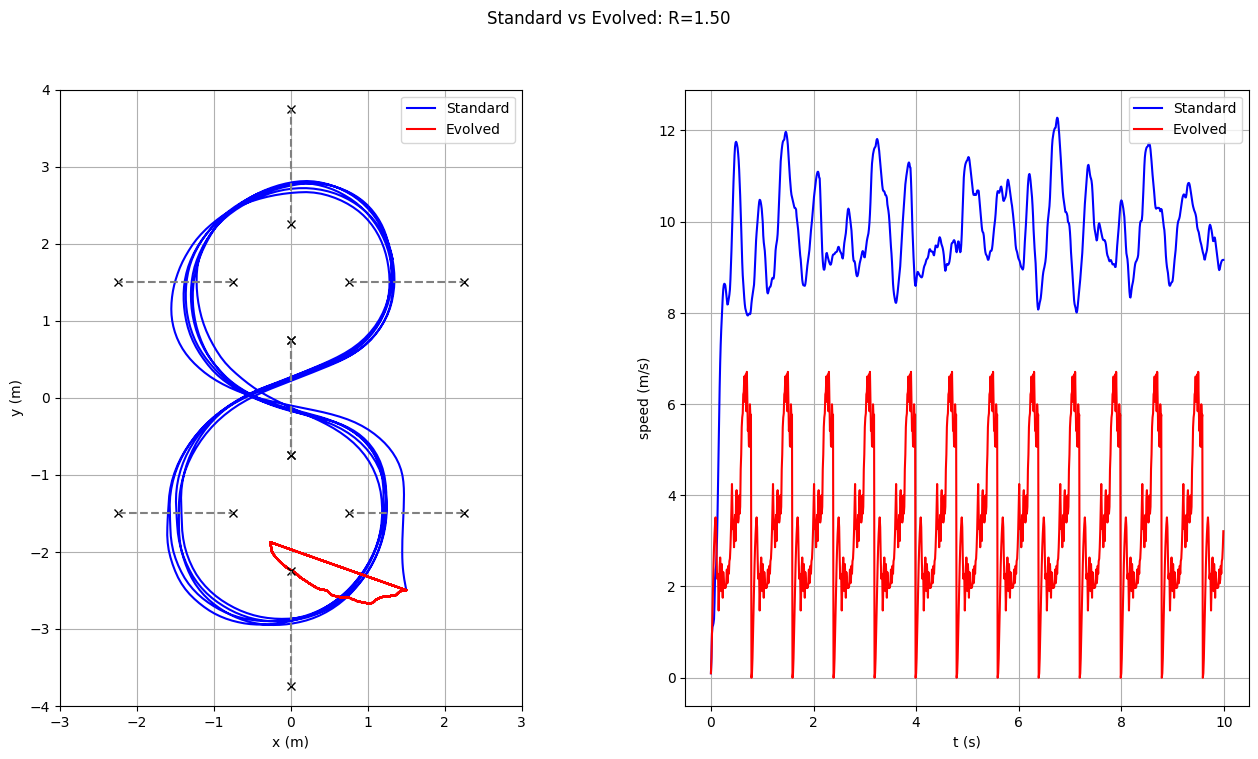

In [11]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig2 = plt.figure(figsize=(16,8))
fig2.suptitle('Standard vs Evolved: R=1.50')

ax21 = fig2.add_subplot(121)
# ax1.scatter(std_position_x, std_position_y, c=std_speed, cmap='viridis')
ax21.plot(std_position_x, std_position_y, label='Standard', color='blue')
ax21.plot(lambda_position_x, lambda_position_y, label='Evolved', color='red')
# norm = Normalize(vmin=min(std_speed), vmax=max(std_speed))
# cbar = plt.colorbar(ScalarMappable(norm=norm, cmap='viridis'), ax=ax1)
# cbar.set_label('Speed (m/s)', rotation=270, labelpad=20)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax21.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax21.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')
    
ax21.legend()
ax21.grid()
ax21.set_aspect('equal')
ax21.set_xlim(-3, 3)
ax21.set_ylim(-4, 4)
ax21.set_xlabel("x (m)")
ax21.set_ylabel("y (m)")

ax22 = fig2.add_subplot(122)
ax22.plot(np.arange(0,10,0.01), std_speed, label='Standard', color='blue')
ax22.plot(np.arange(0,10,0.01), lambda_speed, label='Evolved', color='red')

ax22.legend()
ax22.grid()
ax22.set_xlabel("t (s)")
ax22.set_ylabel("speed (m/s)")

Text(0, 0.5, 'speed (m/s)')

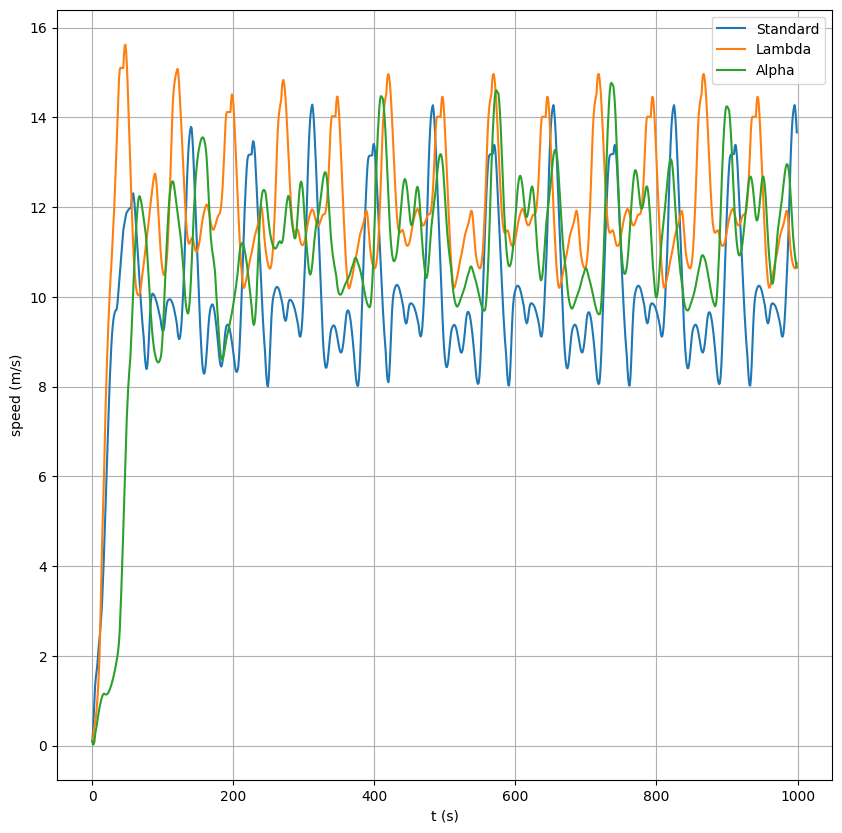

In [24]:
fig3 = plt.figure(figsize=(10,10))
ax31 = fig3.add_subplot(111)
# ax1.scatter(std_position_x, std_position_y, c=std_speed, cmap='viridis')
ax31.plot(range(1000), std_speed, label='Standard')
ax31.plot(range(1000), lambda_speed, label='Lambda')
ax31.plot(range(1000), alpha_speed, label='Alpha')

ax31.legend()
ax31.grid()
ax31.set_xlabel("t (s)")
ax31.set_ylabel("speed (m/s)")

Text(0.5, 1.0, 'Alpha drone')

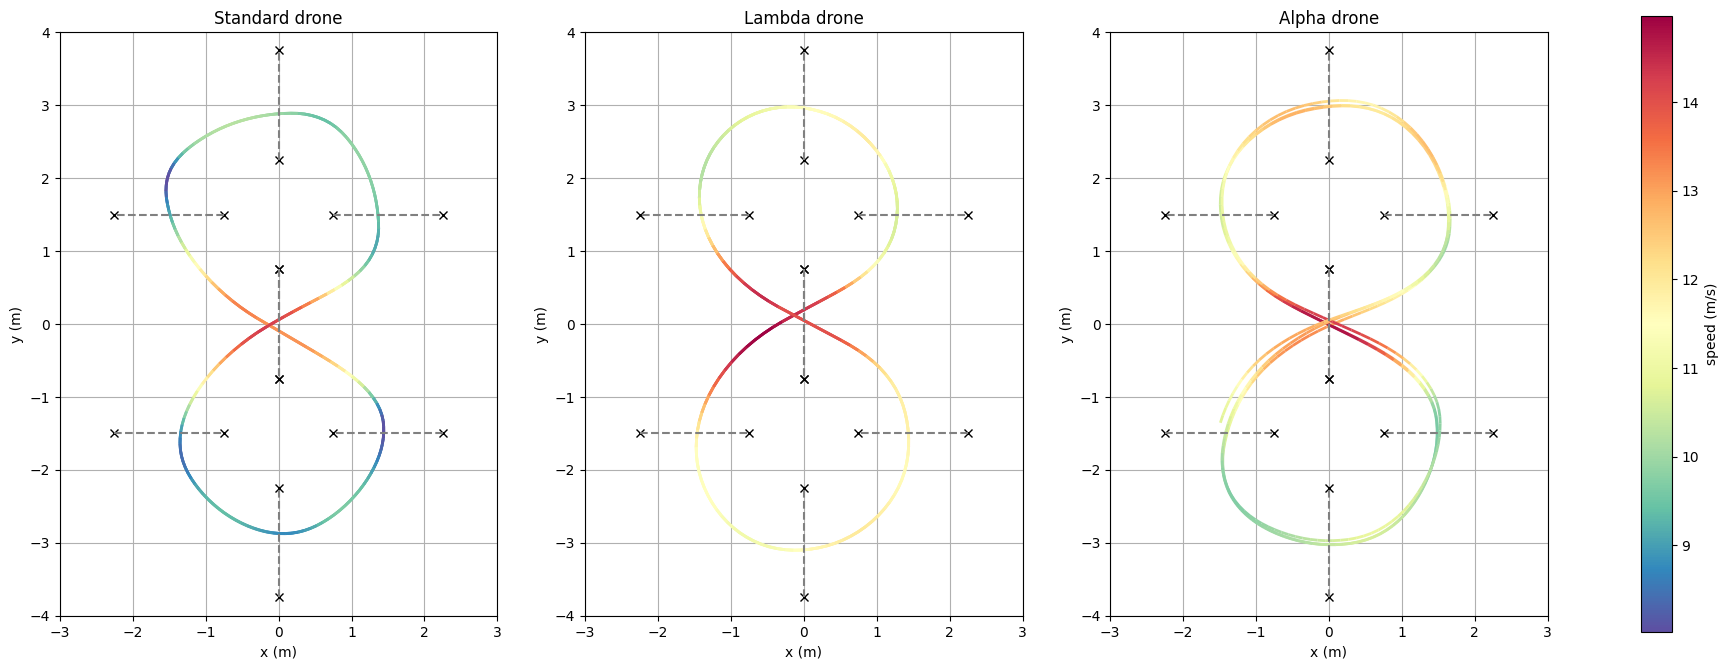

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

idx0 = 500

# Create segments for the line
std_points = np.array([std_position_x[idx0:], std_position_y[idx0:]]).T.reshape(-1, 1, 2)
std_segments = np.concatenate([std_points[:-1], std_points[1:]], axis=1)

# Create a LineCollection
norm = Normalize(min(std_speed[idx0:]+lambda_speed[idx0:]+alpha_speed[idx0:]), max(std_speed[idx0:]+lambda_speed[idx0:]+alpha_speed[idx0:]))  # Normalize color array
std_lc = LineCollection(std_segments, cmap='Spectral_r', norm=norm)
std_lc.set_array(std_speed[idx0:])
std_lc.set_linewidth(2)  # Set line width

# Plot
fig4 = plt.figure(figsize=(24, 8)) 

ax41 = fig4.add_subplot(131)
std_line = ax41.add_collection(std_lc)
ax41.set_xlim(-3, 3)
ax41.set_ylim(-4, 4)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax41.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax41.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Add a colorbar
# cb = plt.colorbar(std_line, ax=ax41)
# cb.set_label('speed (m/s)')

ax41.grid()
ax41.set_xlabel('x (m)')
ax41.set_ylabel('y (m)')
ax41.set_aspect('equal', adjustable='box')
ax41.set_title('Standard drone')


# Create segments for the line
lambda_points = np.array([lambda_position_x[idx0:], lambda_position_y[idx0:]]).T.reshape(-1, 1, 2)
lambda_segments = np.concatenate([lambda_points[:-1], lambda_points[1:]], axis=1)

# Create a LineCollection
lambda_lc = LineCollection(lambda_segments, cmap='Spectral_r', norm=norm)
lambda_lc.set_array(lambda_speed[idx0:])
lambda_lc.set_linewidth(2)  # Set line width

# Plot
ax42 = fig4.add_subplot(132)
lambda_line = ax42.add_collection(lambda_lc)
ax42.set_xlim(-3, 3)
ax42.set_ylim(-4, 4)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax42.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax42.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Add a colorbar
# cb = plt.colorbar(evo_line, ax=ax42)
# cb = fig4.colorbar(lambda_line, ax=[ax41, ax42], orientation='vertical')
# cb.set_label('speed (m/s)')

ax42.grid()
ax42.set_xlabel('x (m)')
ax42.set_ylabel('y (m)')
ax42.set_aspect('equal', adjustable='box')
ax42.set_title('Lambda drone')


# Create segments for the line
alpha_points = np.array([alpha_position_x[idx0:], alpha_position_y[idx0:]]).T.reshape(-1, 1, 2)
alpha_segments = np.concatenate([alpha_points[:-1], alpha_points[1:]], axis=1)

# Create a LineCollection
alpha_lc = LineCollection(alpha_segments, cmap='Spectral_r', norm=norm)
alpha_lc.set_array(alpha_speed[idx0:])
alpha_lc.set_linewidth(2)  # Set line width

# Plot
ax43 = fig4.add_subplot(133)
alpha_line = ax43.add_collection(alpha_lc)
ax43.set_xlim(-3, 3)
ax43.set_ylim(-4, 4)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax43.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax43.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Add a colorbar
# cb = plt.colorbar(evo_line, ax=ax42)
cb = fig4.colorbar(alpha_line, ax=[ax41, ax42, ax43], orientation='vertical')
cb.set_label('speed (m/s)')

ax43.grid()
ax43.set_xlabel('x (m)')
ax43.set_ylabel('y (m)')
ax43.set_aspect('equal', adjustable='box')
ax43.set_title('Alpha drone')

